# P6-B200 AllReduce (NCCL_TESTS_SPLIT_MASK=0x0) - Latency & Bandwidth Roofline Model

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # repo root: roofline_model/ package
from roofline_model import parse_size_str, parse_bw_file, parse_nchannels_table
from roofline_model import (gcp_ring_simple_busbw, gcp_ring_ll_busbw, gcp_ring_ll128_busbw,
                            gcp_tree_simple_busbw, gcp_tree_ll_busbw, gcp_tree_ll128_busbw,
                            PlatformConfig)
cfg = PlatformConfig.load('p6-b200')   # platform hardware params (NIC BW, EFA rails, ...)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

DATA_DIR = '../gcp_AG_AR_results'


# Load nchannels table
nch_table = parse_nchannels_table(os.path.join(DATA_DIR, 'P6-b200_nchannels_table.txt'), section='AllReduce')

# Load AR data files (0x0)
ar_data = {}
for algo in ['ring', 'tree']:
    for proto in ['simple', 'll', 'll128']:
        fname = f'gcp_AR_{algo}_{proto}_0x0.txt'
        fpath = os.path.join(DATA_DIR, fname)
        if os.path.exists(fpath):
            ar_data[(algo, proto)] = parse_bw_file(fpath)
            print(f"Loaded {fname}: {len(ar_data[(algo, proto)])} rows")

# Nchannels column name mapping
nch_col_map = {
    ('ring', 'simple'): '0x0 Ring Simple',
    ('ring', 'll'): '0x0 Ring LL',
    ('ring', 'll128'): '0x0 Ring LL128',
    ('tree', 'simple'): '0x0 Tree Simple',
    ('tree', 'll'): '0x0 Tree LL',
    ('tree', 'll128'): '0x0 Tree LL128',
}

# Protocol-appropriate message size ranges
PROTO_SIZE_RANGES = {
    'simple': (512 * 1024, float('inf')),
    'll': (0, 8 * 1024),
    'll128': (8 * 1024, 512 * 1024),
}

print(f"\nNchannels table columns: {list(nch_table.keys())}")


Loaded gcp_AR_ring_simple_0x0.txt: 31 rows
Loaded gcp_AR_ring_ll_0x0.txt: 25 rows
Loaded gcp_AR_ring_ll128_0x0.txt: 31 rows
Loaded gcp_AR_tree_simple_0x0.txt: 31 rows
Loaded gcp_AR_tree_ll_0x0.txt: 25 rows
Loaded gcp_AR_tree_ll128_0x0.txt: 31 rows

Nchannels table columns: ['0x0 Ring Simple', '0x0 Ring LL', '0x0 Ring LL128', '0x0 Tree Simple', '0x0 Tree LL', '0x0 Tree LL128', '0x7 Ring Simple', '0x7 Ring LL', '0x7 Ring LL128', '0x7 Tree Simple', '0x7 Tree LL', '0x7 Tree LL128']


In [2]:
# Intra-node latency (NCCL cost model: base + (n_gpus-1)*hop) — read from config.json
intra_node_ring_latency_ll     = cfg.intra_node_latency('ring', 'll')
intra_node_ring_latency_ll128  = cfg.intra_node_latency('ring', 'll128')
intra_node_tree_latency        = cfg.intra_node_latency('tree', 'simple')
intra_node_tree_latency_ll     = cfg.intra_node_latency('tree', 'll')
intra_node_tree_latency_ll128  = cfg.intra_node_latency('tree', 'll128')

print(f"intra_node_ring_latency_ll = {intra_node_ring_latency_ll:.1f} us")
print(f"intra_node_ring_latency_ll128 = {intra_node_ring_latency_ll128:.1f} us")
print(f"intra_node_tree_latency = {intra_node_tree_latency:.1f} us")
print(f"intra_node_tree_latency_ll = {intra_node_tree_latency_ll:.1f} us")
print(f"intra_node_tree_latency_ll128 = {intra_node_tree_latency_ll128:.1f} us")

intra_node_ring_latency = 32.2 us
intra_node_ring_latency_ll = 10.8 us
intra_node_ring_latency_ll128 = 27.3 us
intra_node_tree_latency = 36.4 us
intra_node_tree_latency_ll = 11.0 us
intra_node_tree_latency_ll128 = 22.8 us


In [3]:
# Hardware parameters (from config.json)
a = cfg.a_us          # inter-node RTT of small msg (fixed startup latency == alpha)
N_nodes = 16
n_gpus = cfg.n_gpus_per_node
n_total = N_nodes * n_gpus  # 128 GPUs

print(f"a (inter-node RTT, from config) = {a:.4f} us")
print(f"N_nodes = {N_nodes}, n_gpus = {n_gpus}, n_total = {n_total}")

a (inter-node RTT, fixed from mean of msg <= 32B) = 30.6633 us
N_nodes = 16, n_gpus = 8, n_total = 128
NIC_BW = 48750 bytes/us = 48.75 GB/s


In [4]:
# Ring/Simple roofline
busbw_factor = 2 * (n_total - 1) / n_total

fixed_overhead_small = (2 * n_total - 1) * a / 2
fixed_overhead_large = (2 * N_nodes - 1) * a / 2

# Alternate roofline: identical formula, but with a/2 fixed to 3 us
A_HALF_ALT = 2.0  # us (per-step half-latency for the alternate roofline)
fixed_overhead_small_alt = (2 * n_total - 1) * A_HALF_ALT
fixed_overhead_large_alt = (2 * N_nodes - 1) * A_HALF_ALT

nch_col = nch_col_map[('ring', 'simple')]
df = ar_data[('ring', 'simple')].copy()
_lo, _hi = PROTO_SIZE_RANGES['simple']
df = df[(df['size_bytes'] >= _lo) & (df['size_bytes'] <= _hi)].copy()

# Get nchannels per message size
df['nch_raw'] = df['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 32))
df['nch'] = df['nch_raw'].clip(upper=8)

# Compute roofline. nch is the raw NCCL channel count clipped to 8 (p6-b200 has 8 NICs
# per node, so aggregate inter-node BW saturates at 8 channels). Both the roofline time
# and the small/large branch decision use this capped aggregate BW (G_agg).
sizes = df['size_bytes'].values
_nch = df['nch'].values
df['roofline_busbw'] = gcp_ring_simple_busbw(sizes, _nch, N_nodes, n_gpus, a, cfg=cfg)
# Alternate roofline with a/2 = A_HALF_ALT (same formula, different fixed overhead)
df['roofline_busbw_a3'] = gcp_ring_simple_busbw(sizes, _nch, N_nodes, n_gpus, a, half_lat=A_HALF_ALT, cfg=cfg)

print(f"Ring/Simple roofline (N={N_nodes}, n={n_gpus}, n_total={n_total}):")
print(f"  busbw_factor = {busbw_factor:.4f}")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9} {'Roof(a/2=3)':>12}")
print("-" * 64)
for _, row in df.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    size_mb = row['size_bytes'] / (1024**2)
    print(f"{size_mb:>8.1f}MB {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f} {row['roofline_busbw_a3']:>12.2f}")


Ring/Simple roofline (N=16, n=8, n_total=128):
  busbw_factor = 1.9844
  threshold_latency = 700 us

      Size  nch   AWS BW   GCP BW  Roofline  Roof(a/2=3)
----------------------------------------------------------------
     0.5MB   16     0.25     2.59      0.27         2.03
     1.0MB   32     0.49     5.31      0.53         4.04
     2.0MB   32     1.00    10.58      1.06         7.99
     4.0MB   32     1.98    14.17      2.12        15.66
     8.0MB   32     3.91    36.23      4.21        30.12
    16.0MB   32     7.33    59.21      8.33        55.92
    32.0MB   32    12.65    95.75     16.32        97.81
    64.0MB   32    23.27   140.53     31.33       156.40
   128.0MB   32    44.12   182.21     57.99       223.27
   256.0MB   32    82.51   218.67    100.97       283.97
   512.0MB   32   139.69   216.67    332.20       381.34
  1024.0MB   32   220.31   233.52    358.79       385.62
  2048.0MB   32   322.64   249.81    373.74       387.80
  4096.0MB   32   379.23   365.11   

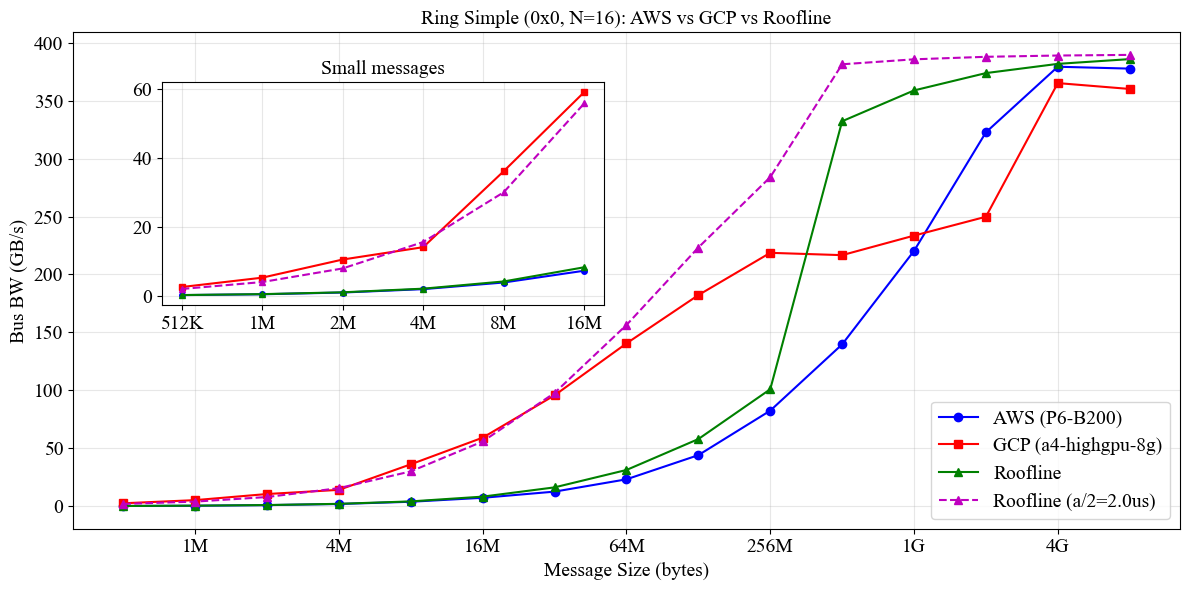

In [5]:
# Plot Ring/Simple
# All text: Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
import matplotlib.ticker as ticker

# X-axis ticks as powers of 2
def format_size(x, p):
    if x <= 0:
        return ''
    if x < 1024:
        return f'{int(x)}B'
    elif x < 1024**2:
        v = x / 1024
        return f'{int(v)}K' if v == int(v) else ''
    elif x < 1024**3:
        v = x / 1024**2
        return f'{int(v)}M' if v == int(v) else ''
    else:
        v = x / 1024**3
        return f'{int(v)}G' if v == int(v) else ''

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df['aws_busbw'].notna()
mask_gcp = df['gcp_busbw'].notna()

if mask_aws.any():
    ax.semilogx(df.loc[mask_aws, 'size_bytes'], df.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (P6-B200)', ms=6)
if mask_gcp.any():
    ax.semilogx(df.loc[mask_gcp, 'size_bytes'], df.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (a4-highgpu-8g)', ms=6)
ax.semilogx(df['size_bytes'], df['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.semilogx(df['size_bytes'], df['roofline_busbw_a3'], 'm^--', label=f'Roofline (a/2={A_HALF_ALT}us)', ms=6)

ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'Ring Simple (0x0, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='lower right', fontsize=14)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

# Inset for small messages (bottom 1/3 of size range)
sizes_sorted = df['size_bytes'].sort_values().values
if len(sizes_sorted) > 4:
    inset_cutoff = sizes_sorted[len(sizes_sorted) // 3]
    df_inset = df[df['size_bytes'] <= inset_cutoff]
    if len(df_inset) > 1:
        axins = ax.inset_axes([0.08, 0.45, 0.4, 0.45])  # [x, y, width, height] in axes coords
        mask_aws_in = df_inset['aws_busbw'].notna()
        mask_gcp_in = df_inset['gcp_busbw'].notna()
        if mask_aws_in.any():
            axins.semilogx(df_inset.loc[mask_aws_in, 'size_bytes'], df_inset.loc[mask_aws_in, 'aws_busbw'], 'bo-', ms=4)
        if mask_gcp_in.any():
            axins.semilogx(df_inset.loc[mask_gcp_in, 'size_bytes'], df_inset.loc[mask_gcp_in, 'gcp_busbw'], 'rs-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw'], 'g^-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw_a3'], 'm^--', ms=4)
        axins.set_title('Small messages', fontsize=14)
        axins.tick_params(labelsize=14)
        axins.xaxis.set_major_locator(ticker.LogLocator(base=2))
        axins.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
        axins.xaxis.set_minor_locator(ticker.NullLocator())
        axins.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(ticker.LogLocator(base=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout()
plt.show()


Ring/LL roofline (N=16, chunk=32KB):
  fixed_per_step = 810.08 us

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
         8   32     0.00      nan      0.00
        16   32     0.00      nan      0.00
        32   32     0.00      nan      0.00
        64   32     0.00      nan      0.00
       128   32     0.00      nan      0.00
       256   32     0.00      nan      0.00
       512   32     0.00      nan      0.00
      1024    1     0.00      nan      0.00
      2048    1     0.00      nan      0.01
      4096    1     0.01     0.06      0.01
      8192    1     0.02     0.13      0.02


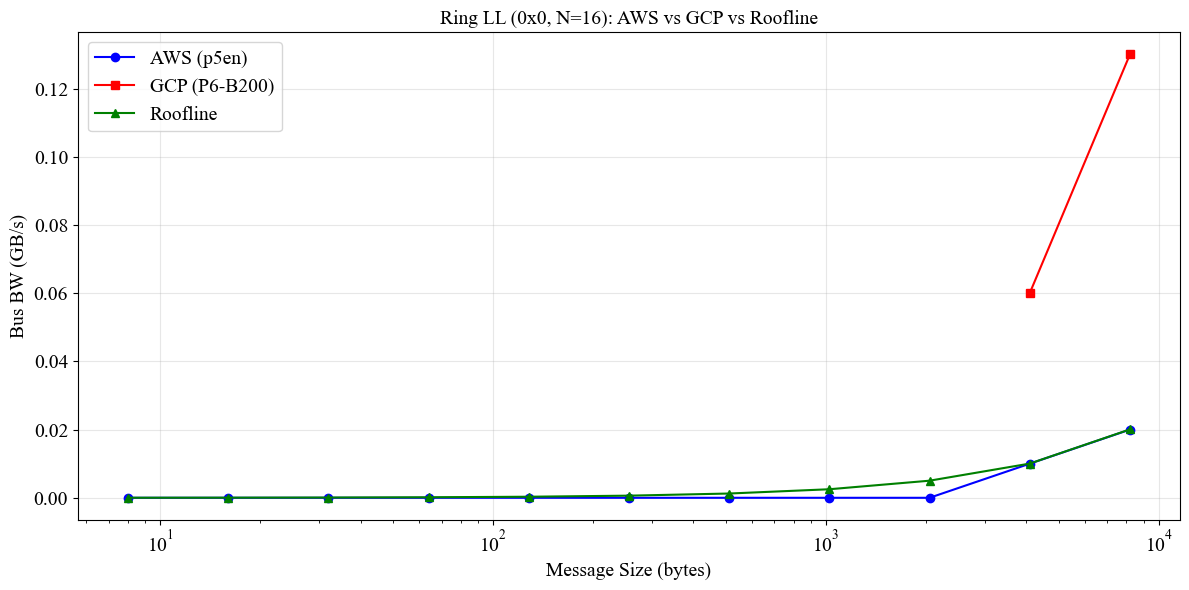

In [6]:
# Ring/LL roofline
chunk_size_ll = 32 * 1024
fixed_per_step_ll = (2 * N_nodes - 1) * (a / 2 + intra_node_ring_latency_ll)

nch_col = nch_col_map[('ring', 'll')]
df_ll = ar_data[('ring', 'll')].copy()
_lo, _hi = PROTO_SIZE_RANGES['ll']
df_ll = df_ll[(df_ll['size_bytes'] >= _lo) & (df_ll['size_bytes'] <= _hi)].copy()

df_ll['nch_raw'] = df_ll['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 32))
df_ll['nch'] = df_ll['nch_raw'].clip(upper=8)

df_ll['roofline_busbw'] = gcp_ring_ll_busbw(df_ll['size_bytes'].values, df_ll['nch_raw'].values,
                                            df_ll['nch'].values, N_nodes, n_gpus, a, intra_node_ring_latency_ll, cfg=cfg)

print(f"Ring/LL roofline (N={N_nodes}, chunk={chunk_size_ll//1024}KB):")
print(f"  fixed_per_step = {fixed_per_step_ll:.2f} us")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_ll.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    print(f"{int(row['size_bytes']):>10} {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot Ring/LL
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_ll['aws_busbw'].notna()
mask_gcp = df_ll['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_ll.loc[mask_aws, 'size_bytes'], df_ll.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_ll.loc[mask_gcp, 'size_bytes'], df_ll.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_ll['size_bytes'], df_ll['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'Ring LL (0x0, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='upper left', fontsize=14)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()


Ring/LL128 roofline (N=16, chunk=576000 bytes):

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
      8192    1     0.02     0.10      0.01
     16384    1     0.03     0.19      0.02
     32768    2     0.07     0.39      0.05
     65536    4     0.13     0.76      0.10
    131072    8     0.26     1.48      0.20
    262144   16     0.44     2.74      0.39
    524288   32     0.90     5.55      0.79


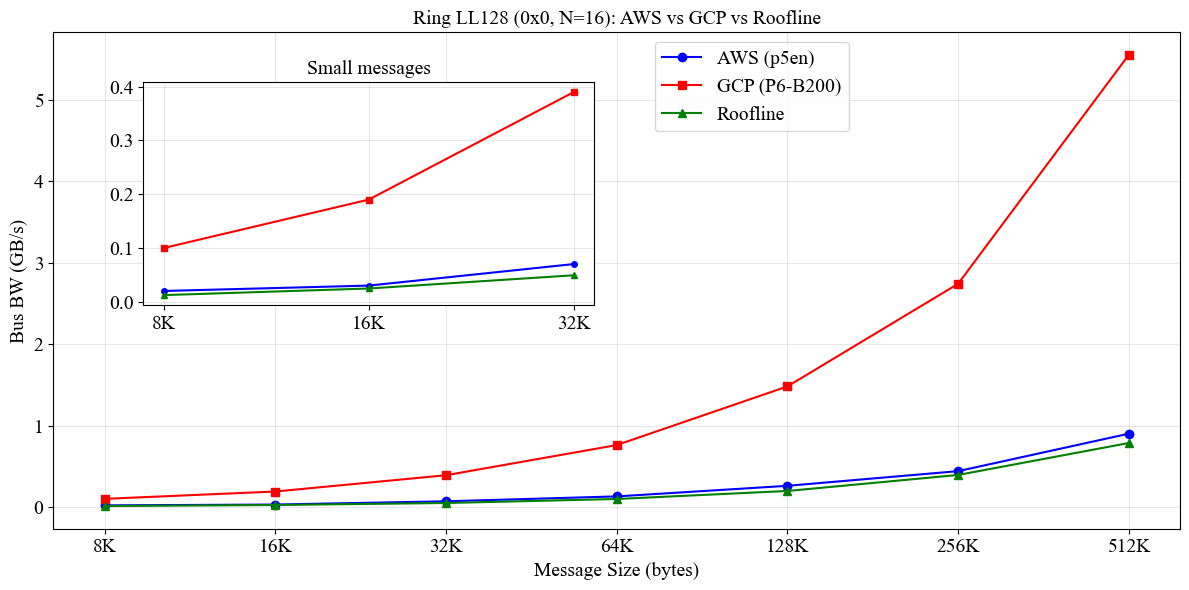

In [7]:
# X-axis ticks as powers of 2
import matplotlib.ticker as ticker
def format_size(x, p):
    if x <= 0:
        return ''
    if x < 1024:
        return f'{int(x)}B'
    elif x < 1024**2:
        v = x / 1024
        return f'{int(v)}K' if v == int(v) else ''
    elif x < 1024**3:
        v = x / 1024**2
        return f'{int(v)}M' if v == int(v) else ''
    else:
        v = x / 1024**3
        return f'{int(v)}G' if v == int(v) else ''

# Ring/LL128 roofline
chunk_size_ll128 = 576000
fixed_per_step_ll128 = (2 * N_nodes - 1) * (a / 2 + intra_node_ring_latency_ll128)  # NCCL Ring/LL128 base latency (14.0), not LL's

nch_col = nch_col_map[('ring', 'll128')]
df_ll128 = ar_data[('ring', 'll128')].copy()
_lo, _hi = PROTO_SIZE_RANGES['ll128']
df_ll128 = df_ll128[(df_ll128['size_bytes'] >= _lo) & (df_ll128['size_bytes'] <= _hi)].copy()

df_ll128['nch_raw'] = df_ll128['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 32))
df_ll128['nch'] = df_ll128['nch_raw'].clip(upper=8)

df_ll128['roofline_busbw'] = gcp_ring_ll128_busbw(df_ll128['size_bytes'].values, df_ll128['nch_raw'].values,
                                                  df_ll128['nch'].values, N_nodes, n_gpus, a, intra_node_ring_latency_ll128, cfg=cfg)

print(f"Ring/LL128 roofline (N={N_nodes}, chunk={chunk_size_ll128} bytes):")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_ll128.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    print(f"{int(row['size_bytes']):>10} {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot Ring/LL128
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_ll128['aws_busbw'].notna()
mask_gcp = df_ll128['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_ll128.loc[mask_aws, 'size_bytes'], df_ll128.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_ll128.loc[mask_gcp, 'size_bytes'], df_ll128.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_ll128['size_bytes'], df_ll128['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'Ring LL128 (0x0, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='upper left', fontsize=14, bbox_to_anchor=(0.525, 1.0))
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

# Inset for small messages
sizes_sorted = df_ll128['size_bytes'].sort_values().values
if len(sizes_sorted) > 4:
    inset_cutoff = sizes_sorted[len(sizes_sorted) // 3]
    df_inset = df_ll128[df_ll128['size_bytes'] <= inset_cutoff]
    if len(df_inset) > 1:
        axins = ax.inset_axes([0.08, 0.45, 0.4, 0.45])
        mask_aws_in = df_inset['aws_busbw'].notna()
        mask_gcp_in = df_inset['gcp_busbw'].notna()
        if mask_aws_in.any():
            axins.semilogx(df_inset.loc[mask_aws_in, 'size_bytes'], df_inset.loc[mask_aws_in, 'aws_busbw'], 'bo-', ms=4)
        if mask_gcp_in.any():
            axins.semilogx(df_inset.loc[mask_gcp_in, 'size_bytes'], df_inset.loc[mask_gcp_in, 'gcp_busbw'], 'rs-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw'], 'g^-', ms=4)
        axins.set_title('Small messages', fontsize=14)
        axins.tick_params(labelsize=14)
        axins.xaxis.set_major_locator(ticker.LogLocator(base=2))
        axins.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
        axins.xaxis.set_minor_locator(ticker.NullLocator())
        axins.grid(True, alpha=0.3)


ax.xaxis.set_major_locator(ticker.LogLocator(base=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout()
plt.show()


Tree/Simple roofline (N=16):
  fixed_overhead = 210.79 us

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
     0.5MB   16     4.73     5.59      4.84
     1.0MB   32     8.94    10.71      9.51
     2.0MB   32    16.10    19.63     18.34
     4.0MB   32    26.13    28.40     34.24
     8.0MB   32    41.91    47.80     60.46
    16.0MB   32    66.28    85.06     97.96
    32.0MB   32    88.57   139.42    142.00
    64.0MB   32   105.47   170.86    183.17
   128.0MB   32   128.81   218.01    214.23
   256.0MB   32      nan   262.25    234.07
   512.0MB   32      nan   257.94    245.44
  1024.0MB   32      nan   271.09    251.55
  2048.0MB   32      nan   336.94    254.72
  4096.0MB   32      nan   343.36    256.33
  8192.0MB   32      nan   338.00    257.15


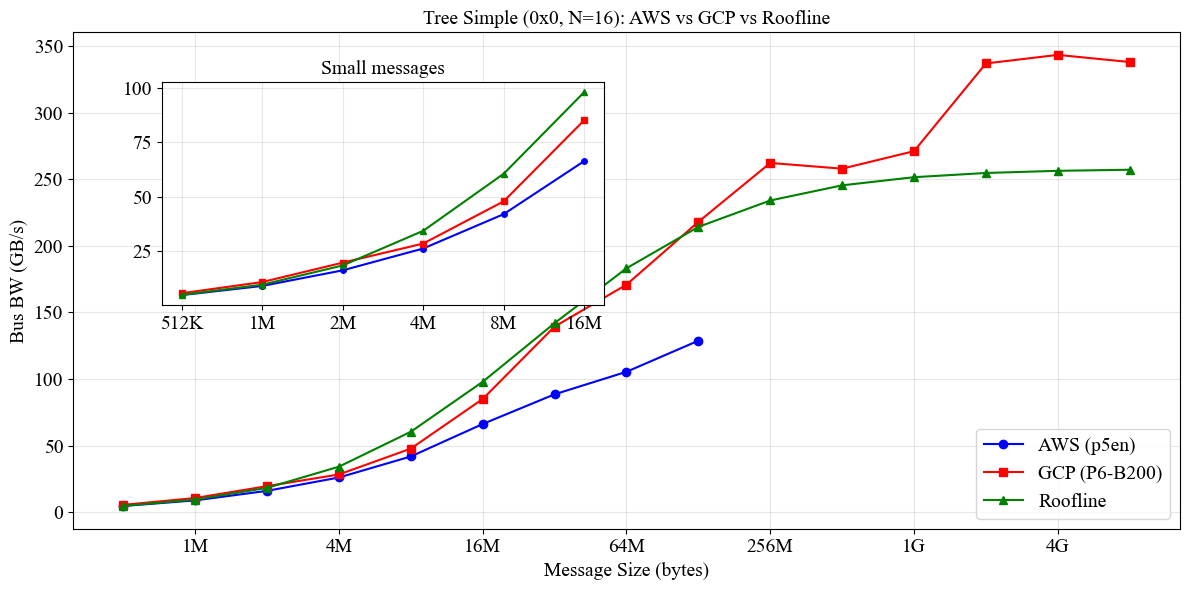

In [8]:
# X-axis ticks as powers of 2
import matplotlib.ticker as ticker
def format_size(x, p):
    if x <= 0:
        return ''
    if x < 1024:
        return f'{int(x)}B'
    elif x < 1024**2:
        v = x / 1024
        return f'{int(v)}K' if v == int(v) else ''
    elif x < 1024**3:
        v = x / 1024**2
        return f'{int(v)}M' if v == int(v) else ''
    else:
        v = x / 1024**3
        return f'{int(v)}G' if v == int(v) else ''

# Tree/Simple roofline
fixed_overhead_tree = (2 * np.log2(N_nodes) + 1) * a / 2 + 2 * intra_node_tree_latency

nch_col = nch_col_map[('tree', 'simple')]
df_ts = ar_data[('tree', 'simple')].copy()
_lo, _hi = PROTO_SIZE_RANGES['simple']
df_ts = df_ts[(df_ts['size_bytes'] >= _lo) & (df_ts['size_bytes'] <= _hi)].copy()

df_ts['nch_raw'] = df_ts['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 32))
df_ts['nch_eff'] = df_ts['nch_raw'].clip(upper=8)

df_ts['roofline_busbw'] = gcp_tree_simple_busbw(df_ts['size_bytes'].values, df_ts['nch_eff'].values,
                                                N_nodes, n_gpus, a, intra_node_tree_latency, cfg=cfg)

print(f"Tree/Simple roofline (N={N_nodes}):")
print(f"  fixed_overhead = {fixed_overhead_tree:.2f} us")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_ts.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    size_mb = row['size_bytes'] / (1024**2)
    print(f"{size_mb:>8.1f}MB {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot Tree/Simple
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_ts['aws_busbw'].notna()
mask_gcp = df_ts['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_ts.loc[mask_aws, 'size_bytes'], df_ts.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_ts.loc[mask_gcp, 'size_bytes'], df_ts.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_ts['size_bytes'], df_ts['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'Tree Simple (0x0, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='lower right', fontsize=14)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

# Inset for small messages
sizes_sorted = df_ts['size_bytes'].sort_values().values
if len(sizes_sorted) > 4:
    inset_cutoff = sizes_sorted[len(sizes_sorted) // 3]
    df_inset = df_ts[df_ts['size_bytes'] <= inset_cutoff]
    if len(df_inset) > 1:
        axins = ax.inset_axes([0.08, 0.45, 0.4, 0.45])
        mask_aws_in = df_inset['aws_busbw'].notna()
        mask_gcp_in = df_inset['gcp_busbw'].notna()
        if mask_aws_in.any():
            axins.semilogx(df_inset.loc[mask_aws_in, 'size_bytes'], df_inset.loc[mask_aws_in, 'aws_busbw'], 'bo-', ms=4)
        if mask_gcp_in.any():
            axins.semilogx(df_inset.loc[mask_gcp_in, 'size_bytes'], df_inset.loc[mask_gcp_in, 'gcp_busbw'], 'rs-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw'], 'g^-', ms=4)
        axins.set_title('Small messages', fontsize=14)
        axins.tick_params(labelsize=14)
        axins.xaxis.set_major_locator(ticker.LogLocator(base=2))
        axins.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
        axins.xaxis.set_minor_locator(ticker.NullLocator())
        axins.grid(True, alpha=0.3)


ax.xaxis.set_major_locator(ticker.LogLocator(base=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout()
plt.show()


Tree/LL roofline (N=16):
  fixed_overhead = 159.99 us

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
         8   32     0.00      nan      0.00
        16   32     0.00      nan      0.00
        32   32     0.00      nan      0.00
        64   32     0.00      nan      0.00
       128   32     0.00      nan      0.00
       256   32     0.00      nan      0.00
       512   32     0.01      nan      0.01
      1024    1     0.01      nan      0.01
      2048    1     0.03      nan      0.03
      4096    1     0.05     0.06      0.05
      8192    2     0.09     0.12      0.10


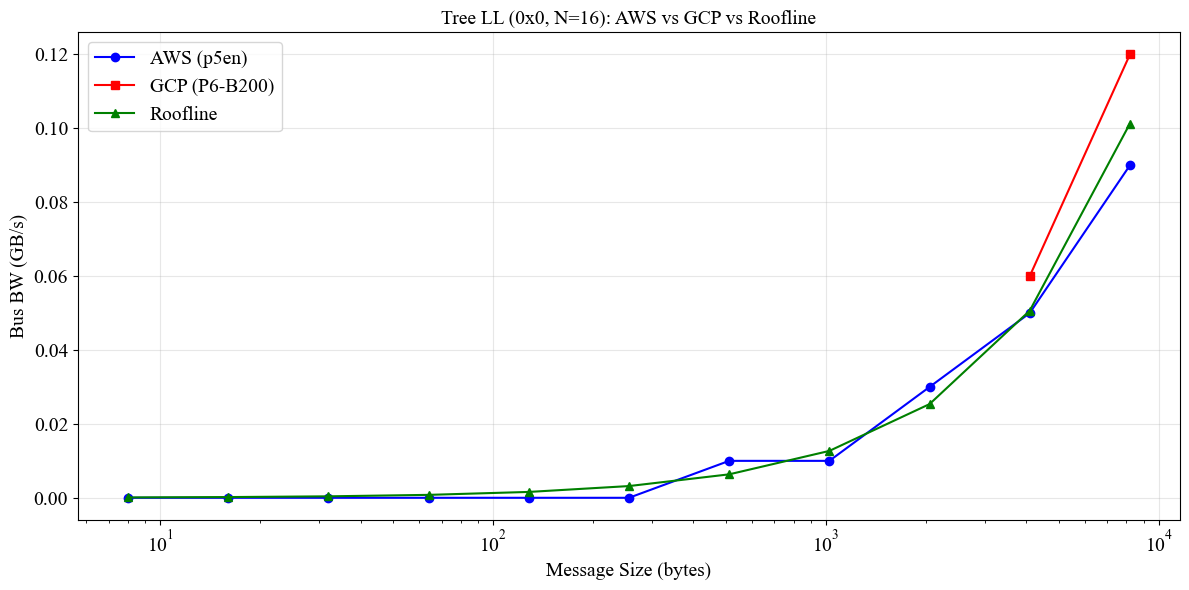

In [9]:
# Tree/LL roofline
fixed_overhead_tree_ll = (2 * np.log2(N_nodes) + 1) * a / 2 + 2 * intra_node_tree_latency_ll

nch_col = nch_col_map[('tree', 'll')]
df_tl = ar_data[('tree', 'll')].copy()
_lo, _hi = PROTO_SIZE_RANGES['ll']
df_tl = df_tl[(df_tl['size_bytes'] >= _lo) & (df_tl['size_bytes'] <= _hi)].copy()

df_tl['nch_raw'] = df_tl['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 32))
df_tl['nch_eff'] = df_tl['nch_raw'].clip(upper=8)

df_tl['roofline_busbw'] = gcp_tree_ll_busbw(df_tl['size_bytes'].values, df_tl['nch_eff'].values,
                                            N_nodes, n_gpus, a, intra_node_tree_latency_ll, cfg=cfg)

print(f"Tree/LL roofline (N={N_nodes}):")
print(f"  fixed_overhead = {fixed_overhead_tree_ll:.2f} us")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_tl.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    print(f"{int(row['size_bytes']):>10} {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot Tree/LL
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_tl['aws_busbw'].notna()
mask_gcp = df_tl['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_tl.loc[mask_aws, 'size_bytes'], df_tl.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_tl.loc[mask_gcp, 'size_bytes'], df_tl.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_tl['size_bytes'], df_tl['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'Tree LL (0x0, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='upper left', fontsize=14)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()


Tree/LL128 roofline (N=16):
  fixed_overhead = 183.49 us

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
      8192    1     0.08     0.10      0.09
     16384    1     0.16     0.20      0.18
     32768    2     0.32     0.39      0.35
     65536    4     0.63     0.75      0.70
    131072    8     1.25     1.46      1.41
    262144   16     2.46     2.76      2.80
    524288   32     4.73     5.59      5.54


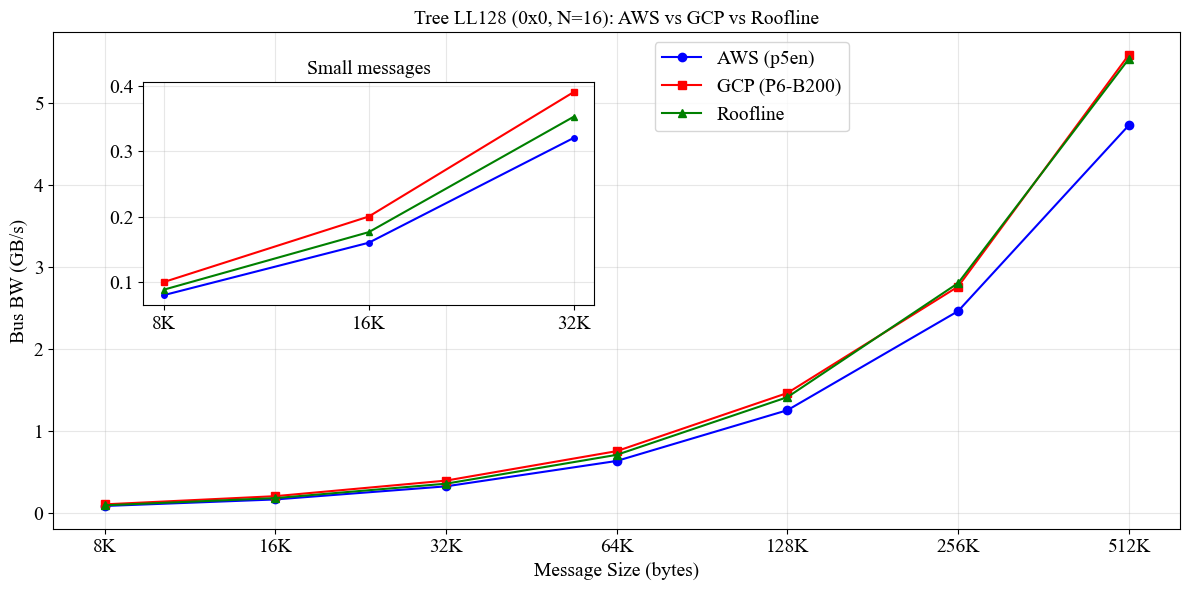

In [10]:
# X-axis ticks as powers of 2
import matplotlib.ticker as ticker
def format_size(x, p):
    if x <= 0:
        return ''
    if x < 1024:
        return f'{int(x)}B'
    elif x < 1024**2:
        v = x / 1024
        return f'{int(v)}K' if v == int(v) else ''
    elif x < 1024**3:
        v = x / 1024**2
        return f'{int(v)}M' if v == int(v) else ''
    else:
        v = x / 1024**3
        return f'{int(v)}G' if v == int(v) else ''

# Tree/LL128 roofline
fixed_overhead_tree_ll128 = (2 * np.log2(N_nodes) + 1) * a / 2 + 2 * intra_node_tree_latency_ll128

nch_col = nch_col_map[('tree', 'll128')]
df_tl128 = ar_data[('tree', 'll128')].copy()
_lo, _hi = PROTO_SIZE_RANGES['ll128']
df_tl128 = df_tl128[(df_tl128['size_bytes'] >= _lo) & (df_tl128['size_bytes'] <= _hi)].copy()

df_tl128['nch_raw'] = df_tl128['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 32))
df_tl128['nch_eff'] = df_tl128['nch_raw'].clip(upper=8)

df_tl128['roofline_busbw'] = gcp_tree_ll128_busbw(df_tl128['size_bytes'].values, df_tl128['nch_eff'].values,
                                                  N_nodes, n_gpus, a, intra_node_tree_latency_ll128, cfg=cfg)

print(f"Tree/LL128 roofline (N={N_nodes}):")
print(f"  fixed_overhead = {fixed_overhead_tree_ll128:.2f} us")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_tl128.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    print(f"{int(row['size_bytes']):>10} {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot Tree/LL128
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_tl128['aws_busbw'].notna()
mask_gcp = df_tl128['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_tl128.loc[mask_aws, 'size_bytes'], df_tl128.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_tl128.loc[mask_gcp, 'size_bytes'], df_tl128.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_tl128['size_bytes'], df_tl128['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'Tree LL128 (0x0, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='upper left', fontsize=14, bbox_to_anchor=(0.525, 1.0))
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

# Inset for small messages
sizes_sorted = df_tl128['size_bytes'].sort_values().values
if len(sizes_sorted) > 4:
    inset_cutoff = sizes_sorted[len(sizes_sorted) // 3]
    df_inset = df_tl128[df_tl128['size_bytes'] <= inset_cutoff]
    if len(df_inset) > 1:
        axins = ax.inset_axes([0.08, 0.45, 0.4, 0.45])
        mask_aws_in = df_inset['aws_busbw'].notna()
        mask_gcp_in = df_inset['gcp_busbw'].notna()
        if mask_aws_in.any():
            axins.semilogx(df_inset.loc[mask_aws_in, 'size_bytes'], df_inset.loc[mask_aws_in, 'aws_busbw'], 'bo-', ms=4)
        if mask_gcp_in.any():
            axins.semilogx(df_inset.loc[mask_gcp_in, 'size_bytes'], df_inset.loc[mask_gcp_in, 'gcp_busbw'], 'rs-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw'], 'g^-', ms=4)
        axins.set_title('Small messages', fontsize=14)
        axins.tick_params(labelsize=14)
        axins.xaxis.set_major_locator(ticker.LogLocator(base=2))
        axins.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
        axins.xaxis.set_minor_locator(ticker.NullLocator())
        axins.grid(True, alpha=0.3)


ax.xaxis.set_major_locator(ticker.LogLocator(base=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout()
plt.show()
